In [1]:
import pandas as pd

In [2]:
dpo = pd.read_csv("final_3/final_dpo-2.csv")
print(dpo.columns)
print(dpo.shape)

Index(['node_id', 'paper_id', 'chosen_persona', 'rejected_persona',
       'rejected_score', 'abstract', 'summary', 'scores', 'neighbours',
       'context', 'n_articles', 'question', 'scope_notes', 'chosen',
       'chosen_falsification_criteria', 'chosen_persona_signature_elements',
       'chosen_evidence_grounding', 'chosen_is_answerable', 'reasoning_chosen',
       'rejected', 'reasoning_rejected', 'rejected_falsification_criteria',
       'rejected_persona_signature_elements', 'rejected_evidence_grounding',
       'rejected_is_answerable', 'index', 'methodology_terms_avoided',
       'question_is_answerable', 'question_unanswerable_reason',
       'reasoning_prompt'],
      dtype='object')
(500, 30)


In [3]:
dpo_clean  = dpo[(dpo['chosen_is_answerable'] == True) & (dpo['rejected_is_answerable'] == True)]
dpo_clean.shape

(492, 30)

In [9]:
dpo_manual_sample = dpo_clean.groupby(['chosen_persona', 'rejected_persona']).sample(n=1, random_state=42)
print(dpo_manual_sample.shape)
print(dpo_manual_sample['chosen_persona'].value_counts())
print(dpo_manual_sample['rejected_persona'].value_counts())

(20, 30)
chosen_persona
data_engineer        4
domain_expert        4
efficient_compute    4
rigorous_skeptic     4
sota_chaser          4
Name: count, dtype: int64
rejected_persona
domain_expert        4
efficient_compute    4
rigorous_skeptic     4
sota_chaser          4
data_engineer        4
Name: count, dtype: int64


In [10]:
dpo_manual_sample = dpo_manual_sample[['chosen_persona','question', 'chosen', 'context', 'chosen_evidence_grounding', 'reasoning_chosen', 'rejected_persona', 'question', 'rejected', 'context', 'rejected_evidence_grounding', 'reasoning_rejected']]
dpo_manual_sample.columns

Index(['chosen_persona', 'question', 'chosen', 'context',
       'chosen_evidence_grounding', 'reasoning_chosen', 'rejected_persona',
       'question', 'rejected', 'context', 'rejected_evidence_grounding',
       'reasoning_rejected'],
      dtype='object')

In [11]:
dpo_manual_sample.to_csv("final_3/data_eval/dpo_manual_sample.csv", index=False)

In [4]:
dpo_clean = dpo_clean[['chosen_persona', 'question', 'context', 'reasoning_chosen', 'reasoning_rejected', 'chosen', 'rejected']].rename(columns={
    'chosen_persona': 'user_id',
    'question': 'question',
    'context': 'context',
    'reasoning_chosen': 'reasoning_chosen',
    'reasoning_rejected': 'reasoning_rejected',
    'chosen': 'chosen',
    'rejected': 'rejected'})
dpo_clean.columns

Index(['user_id', 'question', 'context', 'reasoning_chosen',
       'reasoning_rejected', 'chosen', 'rejected'],
      dtype='object')

In [7]:
dpo_sample = dpo_clean.groupby("user_id").sample(n=5, random_state=42)
dpo_sample.to_csv("final_3/data_eval/dpo-sample.csv", index=False)

In [5]:
dpo_clean.isna().sum()

node_id                                  0
paper_id                                 0
user_id                                  0
rejected_persona                         0
rejected_score                           0
abstract                                 0
summary                                  0
scores                                   0
neighbours                               0
context                                  0
n_articles                               0
question                                 0
scope_notes                              0
chosen                                   0
chosen_falsification_criteria            0
chosen_persona_signature_elements        0
chosen_evidence_grounding                0
chosen_is_answerable                     0
reasoning_chosen                         0
rejected                                 0
reasoning_rejected                       0
rejected_falsification_criteria          0
rejected_persona_signature_elements      0
rejected_ev

In [45]:
dpo_clean = dpo_clean[dpo_clean['strategy'].isin([2, 3])]
dpo_clean.shape

(387, 21)

In [63]:
dpo_sample = dpo_clean.sample(n=150, random_state=42)
dpo_sample.to_csv('dpo_sample.csv', index=False)

In [24]:
dpo_clean.to_csv("final_3/clean/dpo.csv", index=False)

NameError: name 'dpo_clean' is not defined

In [25]:
dpo_clean = pd.read_csv("final_3/clean/dpo.csv")
print(dpo_clean.shape)
print(dpo_clean.columns)
print(dpo_clean.groupby(['user_id', 'rejected_persona']).size())

(492, 30)
Index(['node_id', 'paper_id', 'user_id', 'rejected_persona', 'rejected_score',
       'abstract', 'summary', 'scores', 'neighbours', 'context', 'n_articles',
       'question', 'scope_notes', 'chosen', 'chosen_falsification_criteria',
       'chosen_persona_signature_elements', 'chosen_evidence_grounding',
       'chosen_is_answerable', 'reasoning_chosen', 'rejected',
       'reasoning_rejected', 'rejected_falsification_criteria',
       'rejected_persona_signature_elements', 'rejected_evidence_grounding',
       'rejected_is_answerable', 'index', 'methodology_terms_avoided',
       'question_is_answerable', 'question_unanswerable_reason',
       'reasoning_prompt'],
      dtype='object')
user_id            rejected_persona 
data_engineer      domain_expert        26
                   efficient_compute    23
                   rigorous_skeptic     21
                   sota_chaser          22
domain_expert      data_engineer        27
                   efficient_compute    

In [26]:
print(dpo_clean.groupby('user_id').size())


user_id
data_engineer         92
domain_expert        101
efficient_compute    104
rigorous_skeptic      95
sota_chaser          100
dtype: int64


In [ ]:
manual_eval_dpo = dpo_clean.groupby('user_id').sample(n=5, random_state=42)

In [4]:
dpo_old = pd.read_csv("../data/baseline/sft+dpo/dpo/train.csv")
dpo_old.columns

Index(['user_id', 'question', 'context', 'reasoning_chosen', 'chosen',
       'reasoning_rejected', 'rejected'],
      dtype='object')

In [2]:
cl = pd.read_csv("final_3/final_cl.csv")
print(cl.columns)
print(cl.shape)

Index(['node_id', 'paper_id', 'chosen_persona', 'rejected_persona',
       'rejected_score', 'abstract', 'summary', 'scores', 'neighbours',
       'context', 'n_articles', 'question', 'scope_notes', 'chosen',
       'chosen_falsification_criteria', 'chosen_persona_signature_elements',
       'chosen_evidence_grounding', 'chosen_is_answerable', 'reasoning_chosen',
       'rejected', 'reasoning_rejected', 'rejected_falsification_criteria',
       'rejected_persona_signature_elements', 'rejected_evidence_grounding',
       'rejected_is_answerable', 'methodology_terms_avoided',
       'question_is_answerable', 'question_unanswerable_reason',
       'reasoning_prompt'],
      dtype='object')
(499, 29)


In [7]:
cl_clean = cl[(cl['chosen_is_answerable'] == True) & (cl['rejected_is_answerable'] == True)]
cl_clean = cl_clean.dropna(subset=['chosen_persona', 'question', 'context', 'reasoning_chosen', 'reasoning_rejected', 'chosen', 'rejected'])
cl_clean.shape

(490, 29)

In [8]:
cl_clean.isna().sum()

node_id                                  0
paper_id                                 0
chosen_persona                           0
rejected_persona                         0
rejected_score                           0
abstract                                 0
summary                                  0
scores                                   0
neighbours                               0
context                                  0
n_articles                               0
question                                 0
scope_notes                              0
chosen                                   0
chosen_falsification_criteria            0
chosen_persona_signature_elements        0
chosen_evidence_grounding                0
chosen_is_answerable                     0
reasoning_chosen                         0
rejected                                 0
reasoning_rejected                       0
rejected_falsification_criteria          0
rejected_persona_signature_elements      0
rejected_ev

In [ ]:
cl_clean = cl_clean[['chosen_persona', 'question', 'context', 'reasoning_chosen', 'reasoning_rejected', 'chosen', 'rejected']].rename(columns={
    'chosen_persona': 'user_id',
    'question': 'question',
    'context': 'context',
    'reasoning_chosen': 'reasoning_chosen',
    'reasoning_rejected': 'reasoning_rejected',
    'chosen': 'chosen',
    'rejected': 'rejected'})
cl_clean.columns

Index(['user_id', 'question', 'context', 'reasoning_chosen',
       'reasoning_rejected', 'chosen', 'rejected'],
      dtype='object')

In [10]:
cl_clean.groupby('user_id').size()

user_id
data_engineer         99
domain_expert         99
efficient_compute     98
rigorous_skeptic      94
sota_chaser          100
dtype: int64

In [11]:
cl_data = cl_clean[cl_clean['user_id'] == 'data_engineer']
cl_domain = cl_clean[cl_clean['user_id'] == 'domain_expert']
cl_efficient = cl_clean[cl_clean['user_id'] == 'efficient_compute']
cl_rigorous = cl_clean[cl_clean['user_id'] == 'rigorous_skeptic']
cl_sota = cl_clean[cl_clean['user_id'] == 'sota_chaser']
print(cl_data.shape)
print(cl_domain.shape)
print(cl_efficient.shape)
print(cl_rigorous.shape)
print(cl_sota.shape)

(99, 7)
(99, 7)
(98, 7)
(94, 7)
(100, 7)


In [12]:
cl_data.to_csv('final_3/clean/cl_data.csv', index=False)
cl_domain.to_csv('final_3/clean/cl_domain.csv', index=False)
cl_efficient.to_csv('final_3/clean/cl_efficient.csv', index=False)
cl_rigorous.to_csv('final_3/clean/cl_rigorous.csv', index=False)
cl_sota.to_csv('final_3/clean/cl_sota.csv', index=False)

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

try:
    from sentence_transformers import SentenceTransformer
except ImportError as exc:
    raise ImportError(
        "Install sentence-transformers to run this leakage check: pip install sentence-transformers"
    ) from exc

LEAKAGE_THRESHOLD = 0.90
EMBEDDER_NAME = "sentence-transformers/all-MiniLM-L6-v2"
BASE_DIR = Path("final_3/clean")
PERSONA_FILES = {
    "data_engineer": BASE_DIR / "cl_data.csv",
    "domain_expert": BASE_DIR / "cl_domain.csv",
    "efficient_compute": BASE_DIR / "cl_efficient.csv",
    "rigorous_skeptic": BASE_DIR / "cl_rigorous.csv",
    "sota_chaser": BASE_DIR / "cl_sota.csv",
}


def _find_near_duplicates_by_field(df: pd.DataFrame, persona: str, field: str, model: SentenceTransformer) -> pd.DataFrame:
    """Find near-duplicate pairs based on a single field (chosen or rejected)."""
    texts = df[field].fillna("").astype(str).str.strip()
    embeddings = model.encode(
        texts.tolist(),
        batch_size=32,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    similarity = embeddings @ embeddings.T
    row_idx, col_idx = np.where(np.triu(similarity, k=1) >= LEAKAGE_THRESHOLD)

    rows = []
    for left, right in zip(row_idx, col_idx):
        rows.append({
            "persona": persona,
            "field": field,
            "left_idx": int(left),
            "right_idx": int(right),
            "cosine_similarity": float(similarity[left, right]),
            "left_text": texts.iloc[left][:100],  # truncate for display
            "right_text": texts.iloc[right][:100],
        })

    result = pd.DataFrame(rows)
    if not result.empty:
        result = result.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)
    return result


model = SentenceTransformer(EMBEDDER_NAME)
summary_rows = []
near_duplicate_tables = {}

for persona, file_path in PERSONA_FILES.items():
    df_persona = pd.read_csv(file_path)
    required_cols = {"question", "chosen", "rejected"}
    missing_cols = sorted(required_cols - set(df_persona.columns))
    if missing_cols:
        raise ValueError(f"{file_path} is missing columns required for leakage check: {missing_cols}")

    # Check both chosen and rejected fields
    dup_chosen = _find_near_duplicates_by_field(df_persona, persona, "chosen", model)
    dup_rejected = _find_near_duplicates_by_field(df_persona, persona, "rejected", model)
    
    near_duplicate_tables[f"{persona}_chosen"] = dup_chosen
    near_duplicate_tables[f"{persona}_rejected"] = dup_rejected
    
    summary_rows.append({
        "persona": persona,
        "n_rows": len(df_persona),
        "chosen_duplicates": len(dup_chosen),
        "chosen_max_sim": None if dup_chosen.empty else round(float(dup_chosen["cosine_similarity"].max()), 4),
        "rejected_duplicates": len(dup_rejected),
        "rejected_max_sim": None if dup_rejected.empty else round(float(dup_rejected["cosine_similarity"].max()), 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("persona").reset_index(drop=True)
display(summary_df)

for key, dup_df in near_duplicate_tables.items():
    if not dup_df.empty:
        print(f"\n{key}: {len(dup_df)} near-duplicate pairs (cosine >= {LEAKAGE_THRESHOLD})")
        display(dup_df.head(5))

print(
    "\nUse this to filter in-context demonstrations: "
    "exclude any candidate with similar chosen/rejected hypotheses to your target pair."
)

Skipping import of cpp extensions due to incompatible torch version 2.9.0+cu126 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


README.md: 0.00B [00:00, ?B/s]

,persona,n_rows,near_duplicate_pairs,max_cosine_similarity
0,data_engineer,99,0,None
1,domain_expert,99,0,None
2,efficient_compute,98,0,None
3,rigorous_skeptic,94,0,None
4,sota_chaser,100,0,None



data_engineer: 0 near-duplicate pairs above cosine >= 0.9

domain_expert: 0 near-duplicate pairs above cosine >= 0.9

efficient_compute: 0 near-duplicate pairs above cosine >= 0.9

rigorous_skeptic: 0 near-duplicate pairs above cosine >= 0.9

sota_chaser: 0 near-duplicate pairs above cosine >= 0.9

Use this threshold when sampling in-context demonstrations: exclude any candidate example from the same persona whose combined question+rationale+chosen+rejected embedding is too close to the target.


In [2]:
# Check actual max similarity found per persona (regardless of threshold)
print("Max similarity found in each persona (before threshold filtering):\n")
for persona, file_path in PERSONA_FILES.items():
    df_persona = pd.read_csv(file_path)
    pair_text = _build_pair_text(df_persona)
    embeddings = model.encode(
        pair_text.tolist(),
        batch_size=32,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    similarity = embeddings @ embeddings.T
    max_sim = np.triu(similarity, k=1).max()
    print(f"  {persona:20s} → max_cosine = {max_sim:.4f}, n_pairs_above_0.90 = {len(near_duplicate_tables[persona])}")


Max similarity found in each persona (before threshold filtering):

  data_engineer        → max_cosine = 0.8245, n_pairs_above_0.90 = 0
  domain_expert        → max_cosine = 0.8055, n_pairs_above_0.90 = 0
  efficient_compute    → max_cosine = 0.8233, n_pairs_above_0.90 = 0
  rigorous_skeptic     → max_cosine = 0.7876, n_pairs_above_0.90 = 0
  sota_chaser          → max_cosine = 0.7581, n_pairs_above_0.90 = 0


## Replay
### Perm2

In [16]:
import pandas as pd

RHO = 0.5
SEED = 42

# ── krok 1: sota_chaser (bez replay'a) ────────────────────────────────────────
step1 = cl_sota.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Step 1: total={len(step1)}, sota={len(cl_sota)}")

# ── krok 2: efficient_compute + replay z sota ─────────────────────────────────
n_replay = int(RHO * len(cl_efficient))          # 50
replay_sota = cl_sota.sample(n=n_replay, random_state=SEED+1)
step2 = pd.concat([cl_efficient, replay_sota], ignore_index=True)
step2 = step2.sample(frac=1, random_state=SEED+1).reset_index(drop=True)
print(f"Step 2: total={len(step2)}, efficient={len(cl_efficient)}, "
      f"sota_replay={len(replay_sota)}")

# ── krok 3: rigorous_skeptic + replay z {sota, efficient} ─────────────────────
n_replay = int(RHO * len(cl_rigorous))           # 50
n_per = n_replay // 2                            # 25
replay_sota = cl_sota.sample(n=n_per, random_state=SEED+2)
replay_eff  = cl_efficient.sample(n=n_per, random_state=SEED+20)
step3 = pd.concat([cl_rigorous, replay_sota, replay_eff], ignore_index=True)
step3 = step3.sample(frac=1, random_state=SEED+2).reset_index(drop=True)
print(f"Step 3: total={len(step3)}, rigorous={len(cl_rigorous)}, "
      f"sota={len(replay_sota)}, eff={len(replay_eff)}")

# ── krok 4: data_engineer + replay z {sota, efficient, rigorous} ──────────────
n_replay = int(RHO * len(cl_data))               # 50
n_per = n_replay // 3                            # 16
replay_sota = cl_sota.sample(n=n_per, random_state=SEED+3)
replay_eff  = cl_efficient.sample(n=n_per, random_state=SEED+30)
replay_rig  = cl_rigorous.sample(n=n_per, random_state=SEED+300)
step4 = pd.concat([cl_data, replay_sota, replay_eff, replay_rig], ignore_index=True)
step4 = step4.sample(frac=1, random_state=SEED+3).reset_index(drop=True)
print(f"Step 4: total={len(step4)}, data={len(cl_data)}, "
      f"sota={len(replay_sota)}, eff={len(replay_eff)}, rig={len(replay_rig)}")

# ── krok 5: domain_expert + replay z {sota, efficient, rigorous, data} ────────
n_replay = int(RHO * len(cl_domain))             # 50
n_per = n_replay // 4                            # 12
replay_sota = cl_sota.sample(n=n_per, random_state=SEED+4)
replay_eff  = cl_efficient.sample(n=n_per, random_state=SEED+40)
replay_rig  = cl_rigorous.sample(n=n_per, random_state=SEED+400)
replay_data = cl_data.sample(n=n_per, random_state=SEED+4000)
step5 = pd.concat([cl_domain, replay_sota, replay_eff, replay_rig, replay_data],
                  ignore_index=True)
step5 = step5.sample(frac=1, random_state=SEED+4).reset_index(drop=True)
print(f"Step 5: total={len(step5)}, domain={len(cl_domain)}, "
      f"sota={len(replay_sota)}, eff={len(replay_eff)}, "
      f"rig={len(replay_rig)}, data={len(replay_data)}")

# ── sanity-check kompozycji ───────────────────────────────────────────────────
print("\nKompozycja per krok:")
for i, df in enumerate([step1, step2, step3, step4, step5], 1):
    print(f"  Step {i}: {df['user_id'].value_counts().to_dict()}")

Step 1: total=100, sota=100
Step 2: total=147, efficient=98, sota_replay=49
Step 3: total=140, rigorous=94, sota=23, eff=23
Step 4: total=147, data=99, sota=16, eff=16, rig=16
Step 5: total=147, domain=99, sota=12, eff=12, rig=12, data=12

Kompozycja per krok:
  Step 1: {'sota_chaser': 100}
  Step 2: {'efficient_compute': 98, 'sota_chaser': 49}
  Step 3: {'rigorous_skeptic': 94, 'efficient_compute': 23, 'sota_chaser': 23}
  Step 4: {'data_engineer': 99, 'efficient_compute': 16, 'sota_chaser': 16, 'rigorous_skeptic': 16}
  Step 5: {'domain_expert': 99, 'efficient_compute': 12, 'rigorous_skeptic': 12, 'data_engineer': 12, 'sota_chaser': 12}


In [22]:
step1.to_csv("final_3/clean/perm2/step1.csv", index=False)
step2.to_csv("final_3/clean/perm2/step2.csv", index=False)
step3.to_csv("final_3/clean/perm2/step3.csv", index=False)
step4.to_csv("final_3/clean/perm2/step4.csv", index=False)
step5.to_csv("final_3/clean/perm2/step5.csv", index=False)

In [3]:
sft_old = pd.read_csv("../data/baseline/sft+dpo/sft/train.csv")
sft_old.columns

Index(['user_id', 'question', 'context', 'reasoning', 'answer'], dtype='object')

In [23]:
sft_new = dpo_clean[['node_id','user_id', 'question', 'context', 'reasoning_chosen', 'chosen']].rename(columns={
    'reasoning_chosen': 'reasoning',
    'chosen': 'answer'})
print(sft_new.columns)
print(sft_new.shape)

Index(['node_id', 'user_id', 'question', 'context', 'reasoning', 'answer'], dtype='object')
(492, 6)


In [3]:
test = pd.read_csv("final_3/prompts_test.csv")
print(test.columns)
print(test.shape)

Index(['node_id', 'abstract', 'summary', 'paper_id', 'scores', 'neighbours',
       'chosen_persona', 'rejected_persona', 'rejected_score', 'context',
       'n_articles', 'chosen_hypothesis', 'chosen_falsification_criteria',
       'chosen_persona_signature_elements', 'chosen_evidence_grounding',
       'chosen_is_answerable', 'reasoning_chosen', 'question', 'scope_notes',
       'methodology_terms_avoided', 'question_is_answerable',
       'question_unanswerable_reason', 'reasoning_prompt'],
      dtype='object')
(221, 23)


In [4]:
test_unique = test.drop_duplicates(subset=['node_id'])
print(test_unique.shape)

(178, 23)


In [5]:
test_unique.isna().sum()

node_id                                0
abstract                               0
summary                                0
paper_id                               0
scores                                 0
neighbours                             0
chosen_persona                         0
rejected_persona                       0
rejected_score                         0
context                                0
n_articles                             0
chosen_hypothesis                      0
chosen_falsification_criteria          2
chosen_persona_signature_elements      0
chosen_evidence_grounding              0
chosen_is_answerable                   2
reasoning_chosen                       1
question                               0
scope_notes                            0
methodology_terms_avoided              0
question_is_answerable                 0
question_unanswerable_reason         178
reasoning_prompt                       0
dtype: int64

In [6]:
test_clean = test_unique.rename(columns={
    'chosen_persona': 'user_id',
    'question': 'question',
    'context': 'context',
    'reasoning_chosen': 'reasoning',
    'chosen': 'answer'})
print(test_clean.columns)

Index(['node_id', 'abstract', 'summary', 'paper_id', 'scores', 'neighbours',
       'user_id', 'rejected_persona', 'rejected_score', 'context',
       'n_articles', 'chosen_hypothesis', 'chosen_falsification_criteria',
       'chosen_persona_signature_elements', 'chosen_evidence_grounding',
       'chosen_is_answerable', 'reasoning', 'question', 'scope_notes',
       'methodology_terms_avoided', 'question_is_answerable',
       'question_unanswerable_reason', 'reasoning_prompt'],
      dtype='object')


In [7]:
test_clean = test_clean.groupby('user_id').apply(
    lambda x: x.sample(n=min(30, len(x)), random_state=42)
).reset_index(drop=True)
print(test_clean.shape)


(150, 23)


/tmp/ipykernel_99944/1359641704.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_clean = test_clean.groupby('user_id').apply(


In [11]:
test_clean.groupby('user_id').size()

user_id
data_engineer        30
domain_expert        30
efficient_compute    30
rigorous_skeptic     30
sota_chaser          30
dtype: int64

In [12]:
test_clean['node_id'].duplicated().sum()

np.int64(0)

In [13]:
test_clean.to_csv("final_3/clean/test.csv", index=False)

In [25]:
sft_new_unique = sft_new.drop_duplicates(subset=['node_id'])
print(sft_new_unique.shape)

(427, 6)


In [26]:
sft_new.to_csv("final_3/clean/sft.csv", index=False)

In [2]:
sft_new = pd.read_csv("final_3/final_sft.csv")
print(sft_new.shape)
sft_new.columns

(1000, 29)


Index(['node_id', 'paper_id', 'chosen_persona', 'rejected_persona',
       'rejected_score', 'abstract', 'summary', 'scores', 'neighbours',
       'context', 'n_articles', 'question', 'scope_notes', 'chosen',
       'chosen_falsification_criteria', 'chosen_persona_signature_elements',
       'chosen_evidence_grounding', 'chosen_is_answerable', 'reasoning_chosen',
       'rejected', 'reasoning_rejected', 'rejected_falsification_criteria',
       'rejected_persona_signature_elements', 'rejected_evidence_grounding',
       'rejected_is_answerable', 'methodology_terms_avoided',
       'question_is_answerable', 'question_unanswerable_reason',
       'reasoning_prompt'],
      dtype='object')

In [4]:
sft_clean  = sft_new[sft_new['chosen_is_answerable'] == True]
sft_clean  = sft_clean[sft_clean['context'].notna()]

sft_clean.shape

(985, 29)

In [6]:
# 1. Define the mapping for Chosen columns
sft_chosen = sft_clean[[
    'node_id', 'chosen', 
    'context', 'reasoning_chosen', 'question', 'chosen_persona'
]].rename(columns={
    'chosen': 'answer',
    'context': 'context',
    'reasoning_chosen': 'reasoning',
    'question': 'question',
    'chosen_persona': 'user_id'
})

# 2. Define the mapping for Rejected columns
# sft_rejected = sft_clean[[
#     'initial_node', 'neighbor_node', 'rejected_hypothesis', 
#     'rejected_context', 'rejected_reasoning', 'rejected_prompt', 'rejected_persona'
# ]].rename(columns={
#     'rejected_hypothesis': 'answer',
#     'rejected_context': 'context',
#     'rejected_reasoning': 'reasoning',
#     'rejected_prompt': 'question',
#     'rejected_persona': 'user_id'
# })

# # 3. Stack them vertically
# combined_sft = pd.concat([sft_chosen, sft_rejected], ignore_index=True)

# # 4. Get unique values based on your nodes
# # This removes duplicates where the combination of all these columns is identical
# final_sft = combined_sft.drop_duplicates(subset=['initial_node', 'neighbor_node', 'question', 'answer'])
# print(final_sft.columns)
# print(final_sft.shape)

In [7]:
final_sft_cleaned = sft_chosen[sft_chosen['answer'].notna()]
print(final_sft_cleaned.shape)

(985, 6)


In [8]:
sft_unique_rows = final_sft_cleaned.drop_duplicates(subset=['node_id'])

print(sft_unique_rows.shape)
print(sft_unique_rows.columns)

(859, 6)
Index(['node_id', 'answer', 'context', 'reasoning', 'question', 'user_id'], dtype='object')


In [9]:
sft_unique_rows.isna().sum()

node_id      0
answer       0
context      0
reasoning    0
question     0
user_id      0
dtype: int64

In [10]:
sft_unique_rows.to_csv("final_3/clean/sft.csv", index=False)

In [2]:
sft_unique = pd.read_csv("final_3/clean/sft.csv")
print(sft_unique.shape)
print(sft_unique.columns)


(859, 6)
Index(['node_id', 'answer', 'context', 'reasoning', 'question', 'user_id'], dtype='object')


In [3]:
sft_unique.groupby('user_id').size()

user_id
data_engineer        169
domain_expert        183
efficient_compute    171
rigorous_skeptic     149
sota_chaser          187
dtype: int64

In [23]:
sft_clean = sft_clean.rename(columns={
    'chosen_persona': 'user_id',
    'chosen_prompt': 'question',
    'chosen_context': 'context',
    'chosen_reasoning': 'reasoning',
    'chosen_hypothesis': 'answer',
})
sft_clean.columns

Index(['pair_id', 'initial_node', 'neighbor_node', 'initial_persona',
       'target_persona', 'initial_persona_score', 'target_persona_score',
       'relationship_type', 'question', 'chosen_concepts', 'context',
       'chosen_context_meta', 'answer', 'reasoning', 'rejected_hypothesis',
       'rejected_reasoning', 'chosen_is_answerable', 'rejected_is_answerable',
       'chosen_n_chunks', 'chosen_average_rerank_score',
       'chosen_average_rerank_score_per_concept', 'n_excluded_nodes',
       'chosen_abstract', 'chosen_summary', 'chosen_paper_id',
       'initial_scores', 'neighbor_scores', 'synthetic', 'strategy', 'backend',
       'error'],
      dtype='object')

In [42]:
sft_clean.to_csv("sft_hypotheses_shorter_context_qwen3.5-122B-A10B-fp8_clean.csv", index=False)

In [16]:
val_new_dpo = pd.read_csv("final_3/final_val.csv")
print(val_new_dpo.shape)
val_new_dpo.columns

(100, 29)


Index(['node_id', 'paper_id', 'chosen_persona', 'rejected_persona',
       'rejected_score', 'abstract', 'summary', 'scores', 'neighbours',
       'context', 'n_articles', 'question', 'scope_notes', 'chosen',
       'chosen_falsification_criteria', 'chosen_persona_signature_elements',
       'chosen_evidence_grounding', 'chosen_is_answerable', 'reasoning_chosen',
       'rejected', 'reasoning_rejected', 'rejected_falsification_criteria',
       'rejected_persona_signature_elements', 'rejected_evidence_grounding',
       'rejected_is_answerable', 'methodology_terms_avoided',
       'question_is_answerable', 'question_unanswerable_reason',
       'reasoning_prompt'],
      dtype='object')

In [18]:
val_old_dpo = pd.read_csv("../data/baseline/sft+dpo/dpo/val.csv")
val_old_dpo.columns

Index(['user_id', 'question', 'context', 'reasoning_chosen', 'chosen',
       'reasoning_rejected', 'rejected'],
      dtype='object')

In [17]:
val_new_dpo = val_new_dpo.rename(columns={
    'chosen_persona': 'user_id',
    'question': 'question',
    'context': 'context',
    'reasoning_chosen': 'reasoning_chosen',
    'reasoning_rejected': 'reasoning_rejected',
    'chosen': 'chosen',
    'rejected': 'rejected'})
val_new_dpo.columns

Index(['node_id', 'paper_id', 'user_id', 'rejected_persona', 'rejected_score',
       'abstract', 'summary', 'scores', 'neighbours', 'context', 'n_articles',
       'question', 'scope_notes', 'chosen', 'chosen_falsification_criteria',
       'chosen_persona_signature_elements', 'chosen_evidence_grounding',
       'chosen_is_answerable', 'reasoning_chosen', 'rejected',
       'reasoning_rejected', 'rejected_falsification_criteria',
       'rejected_persona_signature_elements', 'rejected_evidence_grounding',
       'rejected_is_answerable', 'methodology_terms_avoided',
       'question_is_answerable', 'question_unanswerable_reason',
       'reasoning_prompt'],
      dtype='object')

In [18]:
val_new_dpo = val_new_dpo[(val_new_dpo['chosen_is_answerable'] == True) & (val_new_dpo['rejected_is_answerable'] == True)]
val_new_dpo.shape

(99, 29)

In [51]:
val_new_dpo = val_new_dpo[val_new_dpo['strategy'].isin([2, 3])]
val_new_dpo.shape

(86, 21)

In [19]:
val_new_dpo.isna().sum()

node_id                                 0
paper_id                                0
user_id                                 0
rejected_persona                        0
rejected_score                          0
abstract                                0
summary                                 0
scores                                  0
neighbours                              0
context                                 0
n_articles                              0
question                                0
scope_notes                             1
chosen                                  0
chosen_falsification_criteria           0
chosen_persona_signature_elements       0
chosen_evidence_grounding               0
chosen_is_answerable                    0
reasoning_chosen                        0
rejected                                0
reasoning_rejected                      0
rejected_falsification_criteria         0
rejected_persona_signature_elements     0
rejected_evidence_grounding       

In [20]:
val_new_dpo.to_csv("final_3/clean/val_dpo.csv", index=False)

In [8]:
val_dpo = pd.read_csv("final_3/clean/val_dpo.csv")
print(val_dpo.shape)

(99, 29)


In [9]:
val_dpo.groupby(['user_id', 'rejected_persona']).size()

user_id            rejected_persona 
data_engineer      domain_expert        5
                   efficient_compute    6
                   rigorous_skeptic     6
                   sota_chaser          5
domain_expert      data_engineer        5
                   efficient_compute    6
                   rigorous_skeptic     5
                   sota_chaser          6
efficient_compute  data_engineer        6
                   domain_expert        5
                   rigorous_skeptic     4
                   sota_chaser          4
rigorous_skeptic   data_engineer        5
                   domain_expert        5
                   efficient_compute    5
                   sota_chaser          3
sota_chaser        data_engineer        4
                   domain_expert        5
                   efficient_compute    4
                   rigorous_skeptic     5
dtype: int64

In [27]:
val_old_sft = pd.read_csv("../data/baseline/sft+dpo/sft/val.csv")
val_old_sft.columns

Index(['user_id', 'question', 'context', 'reasoning', 'answer'], dtype='object')

In [27]:
val_new_sft = val_new_dpo[[
    'node_id',
    'user_id', 'chosen', 
    'context', 'reasoning_chosen', 'question'
]].rename(columns={
    'chosen': 'answer',
    'reasoning_chosen': 'reasoning',
})
val_new_sft.columns


Index(['node_id', 'user_id', 'answer', 'context', 'reasoning', 'question'], dtype='object')

In [28]:
val_sft_unique_rows = val_new_sft.drop_duplicates(subset=['node_id'])

print(val_sft_unique_rows.shape)

(85, 6)


In [29]:
val_sft_unique_rows.to_csv("final_3/clean/val_sft.csv", index=False)

In [5]:
val_sft_unique_rows = pd.read_csv("final_3/clean/val_sft.csv")
print(val_sft_unique_rows.shape)
print(val_sft_unique_rows.columns)
print(val_sft_unique_rows.groupby('user_id').size())

(85, 6)
Index(['node_id', 'user_id', 'answer', 'context', 'reasoning', 'question'], dtype='object')
user_id
data_engineer        19
domain_expert        21
efficient_compute    15
rigorous_skeptic     13
sota_chaser          17
dtype: int64


In [16]:
test_old = pd.read_csv("../data/baseline/sft+dpo/dpo/test.csv")
test_old.columns

Index(['user_id', 'question', 'context', 'reasoning_chosen', 'chosen',
       'reasoning_rejected', 'rejected'],
      dtype='object')

In [17]:
test_new = pd.read_csv("test_new_prompts_qwen3.5.csv")
print(test_new.shape)
print(test_new.columns)

(580, 16)
Index(['pair_id', 'initial_node', 'neighbor_node', 'initial_persona',
       'target_persona', 'initial_persona_score', 'target_persona_score',
       'relationship_type', 'chosen_prompt', 'chosen_reasoning',
       'chosen_abstract', 'chosen_summary', 'chosen_paper_id',
       'initial_scores', 'neighbor_scores', 'synthetic'],
      dtype='object')


In [18]:
test_new = test_new[['initial_persona', 'chosen_prompt', 'chosen_context', 'chosen_reasoning']].rename(columns={
    'initial_persona': 'user_id',
    'chosen_prompt': 'question',
    'chosen_context': 'context',
    'chosen_reasoning': 'reasoning',
})
test_new.columns

KeyError: "['chosen_context'] not in index"

In [2]:
df_eval = pd.read_csv("final_3/clean/eval_result-gemma.csv")
print(df_eval.shape)
print(df_eval.columns)

(50, 16)
Index(['node_id', 'paper_id', 'persona', 'persona_display_name',
       'hypothesis_type', 'hypothesis', 'context', 'question', 'clarity_score',
       'clarity_reasoning', 'groundedness_score', 'groundedness_reasoning',
       'relevancy_score', 'relevancy_reasoning', 'persona_adherence_score',
       'persona_adherence_reasoning'],
      dtype='object')


In [4]:
df_plain = df_eval[['node_id', 'persona', 'hypothesis_type', 'hypothesis', 'context', 'question']]
df_plain.columns

Index(['node_id', 'persona', 'hypothesis_type', 'hypothesis', 'context',
       'question'],
      dtype='object')

In [5]:
df_plain.to_csv("final_3/clean/hypotheses.csv", index=False)

### Old DPO data eval preparation

In [2]:
df = pd.read_csv("final_2/dpo_new_hypotheses_qwen3.5.csv")
print(df.shape)
print(df.columns)

(500, 33)
Index(['pair_id', 'initial_node', 'neighbor_node', 'initial_persona',
       'target_persona', 'initial_persona_score', 'target_persona_score',
       'relationship_type', 'chosen_prompt', 'chosen_concepts',
       'chosen_context', 'chosen_context_meta', 'chosen_hypothesis',
       'chosen_reasoning', 'rejected_hypothesis', 'rejected_reasoning',
       'chosen_is_answerable', 'rejected_is_answerable',
       'chosen_falsification_criteria', 'rejected_falsification_criteria',
       'chosen_n_chunks', 'chosen_average_rerank_score',
       'chosen_average_rerank_score_per_concept', 'n_excluded_nodes',
       'chosen_abstract', 'chosen_summary', 'chosen_paper_id',
       'initial_scores', 'neighbor_scores', 'synthetic', 'strategy', 'backend',
       'error'],
      dtype='object')


In [6]:
df_comparison = pd.read_csv("final_3/final_dpo-2.csv")
print(df_comparison.shape)
print(df_comparison.columns)

(500, 30)
Index(['node_id', 'paper_id', 'chosen_persona', 'rejected_persona',
       'rejected_score', 'abstract', 'summary', 'scores', 'neighbours',
       'context', 'n_articles', 'question', 'scope_notes', 'chosen',
       'chosen_falsification_criteria', 'chosen_persona_signature_elements',
       'chosen_evidence_grounding', 'chosen_is_answerable', 'reasoning_chosen',
       'rejected', 'reasoning_rejected', 'rejected_falsification_criteria',
       'rejected_persona_signature_elements', 'rejected_evidence_grounding',
       'rejected_is_answerable', 'index', 'methodology_terms_avoided',
       'question_is_answerable', 'question_unanswerable_reason',
       'reasoning_prompt'],
      dtype='object')


In [5]:
df.groupby(['initial_persona', 'target_persona']).size()

initial_persona    target_persona   
data_engineer      domain_expert        18
                   efficient_compute    27
                   rigorous_skeptic     30
                   sota_chaser          22
domain_expert      data_engineer        20
                   efficient_compute    32
                   rigorous_skeptic     25
                   sota_chaser          19
efficient_compute  data_engineer        20
                   domain_expert        38
                   rigorous_skeptic     23
                   sota_chaser          26
rigorous_skeptic   data_engineer        21
                   domain_expert        17
                   efficient_compute    35
                   sota_chaser          30
sota_chaser        data_engineer        34
                   domain_expert        28
                   efficient_compute    19
                   rigorous_skeptic     16
dtype: int64

In [9]:
df_renamed = df.rename(columns={
    'initial_node': 'node_id',
    'initial_persona': 'chosen_persona',
    'target_persona': 'rejected_persona',
    'chosen_prompt': 'question',
    'chosen_context': 'context',
    'chosen_hypothesis': 'chosen',
    'rejected_hypothesis': 'rejected',
})

In [10]:
df_renamed.to_csv("final_2/dpo_eval_format.csv", index=False)

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-1.7B"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

# prepare the model input
prompt = "Tell me a joke"
messages = [
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True # Switches between thinking and non-thinking modes. Default is True.
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# conduct text completion
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=32768
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist() 

# parsing thinking content
try:
    # rindex finding 151668 (</think>)
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

thinking_content = tokenizer.decode(output_ids[:index], skip_special_tokens=True).strip("\n")
content = tokenizer.decode(output_ids[index:], skip_special_tokens=True).strip("\n")

print("thinking content:", thinking_content)
print("content:", content)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

Skipping import of cpp extensions due to incompatible torch version 2.9.0+cu126 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/622M [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [3]:
ids = tokenizer.encode("<think>some reasoning</think>answer")
print(tokenizer.convert_ids_to_tokens(ids))

['<think>', 'some', 'Ġreasoning', '</think>', 'answer']


In [4]:
print(tokenizer.chat_template)

{%- if tools %}
    {{- '<|im_start|>system\n' }}
    {%- if messages[0].role == 'system' %}
        {{- messages[0].content + '\n\n' }}
    {%- endif %}
    {{- "# Tools\n\nYou may call one or more functions to assist with the user query.\n\nYou are provided with function signatures within <tools></tools> XML tags:\n<tools>" }}
    {%- for tool in tools %}
        {{- "\n" }}
        {{- tool | tojson }}
    {%- endfor %}
    {{- "\n</tools>\n\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\n<tool_call>\n{\"name\": <function-name>, \"arguments\": <args-json-object>}\n</tool_call><|im_end|>\n" }}
{%- else %}
    {%- if messages[0].role == 'system' %}
        {{- '<|im_start|>system\n' + messages[0].content + '<|im_end|>\n' }}
    {%- endif %}
{%- endif %}
{%- set ns = namespace(multi_step_tool=true, last_query_index=messages|length - 1) %}
{%- for message in messages[::-1] %}
    {%- set index = (messages|length - 

In [6]:
print(tokenizer.encode("<think>"))   # should be single token ID
print(tokenizer.encode("</think>")) 

[151667]
[151668]


In [3]:
gen = pd.read_csv("final_3/clean/tmp/eval_results_generate_dpo-10.1.csv")
print(gen.columns)
print(gen.shape)

Index(['user_id', 'question', 'context', 'trained_response',
       'trained_reasoning', 'trained_raw', 'trained_fs_response',
       'trained_fs_reasoning', 'trained_fs_raw', 'base_response',
       'base_reasoning', 'base_raw', 'base_fs_response', 'base_fs_reasoning',
       'base_fs_raw'],
      dtype='object')
(149, 15)


In [4]:
gen_sample = gen.groupby('user_id').sample(n=5)
print(gen_sample.shape)

(25, 15)


In [5]:
gen_sample.to_csv("final_3/clean/gen_sample.csv", index=False)

In [2]:
sample = pd.read_csv("final_3/sample/sample.csv")
print(sample.columns)
print(sample.shape)

Index(['user_id', 'question', 'context', 'trained_response',
       'trained_reasoning', 'trained_raw', 'trained_fs_response',
       'trained_fs_reasoning', 'trained_fs_raw', 'base_response',
       'base_reasoning', 'base_raw', 'base_fs_response', 'base_fs_reasoning',
       'base_fs_raw'],
      dtype='object')
(149, 15)


In [3]:
sample_small = sample.groupby('user_id').sample(n=10)
print(sample_small.shape)

(50, 15)


In [5]:
sample_small = sample_small.drop(['trained_raw', 'trained_fs_raw', 'base_raw', 'base_fs_raw'], axis=1)
print(sample_small.columns)

Index(['user_id', 'question', 'context', 'trained_response',
       'trained_reasoning', 'trained_fs_response', 'trained_fs_reasoning',
       'base_response', 'base_reasoning', 'base_fs_response',
       'base_fs_reasoning'],
      dtype='object')


In [9]:
sample_small.to_csv("final_3/sample/sample_personas.csv", index=False)

In [10]:
dpo_pro = pd.read_csv("final_4/final_dpo-3.csv")
print(dpo_pro.columns)
print(dpo_pro.shape)

Index(['node_id', 'paper_id', 'chosen_persona', 'rejected_persona',
       'rejected_score', 'abstract', 'summary', 'scores', 'neighbours',
       'context', 'n_articles', 'question', 'scope_notes', 'chosen',
       'chosen_falsification_criteria', 'chosen_persona_signature_elements',
       'chosen_evidence_grounding', 'chosen_is_answerable', 'reasoning_chosen',
       'rejected', 'reasoning_rejected', 'rejected_falsification_criteria',
       'rejected_persona_signature_elements', 'rejected_evidence_grounding',
       'rejected_is_answerable', 'index', 'methodology_terms_avoided',
       'question_is_answerable', 'question_unanswerable_reason',
       'reasoning_prompt'],
      dtype='object')
(15, 30)


In [11]:
dpo_pro_clean = dpo_pro[(dpo_pro['chosen_is_answerable'] == True) & (dpo_pro['rejected_is_answerable'] == True)]
dpo_pro_clean.shape

(14, 30)

In [12]:
dpo_pro_clean.to_csv("final_4/dpo.csv", index=False)

## Rationale columns for DPO training

Dla każdego przykładu w zbiorach `cl_*`, `val_dpo` i `test` dodajemy:
- `rationale_chosen` — hipoteza zaakceptowana z innego przykładu tej samej persony
- `rationale_rejected` — hipoteza odrzucona z innego przykładu tej samej persony
- `rationale_train` — wyjaśnienie dlaczego chosen > rejected (z kolumny `rationale`)
- `rationale_question` — pytanie z przykładu rationale

Ograniczenie: przykład rationale musi mieć inny `node_id` niż pytanie treningowe.  
Dla testu: pula rationale pochodzi ze zbioru walidacyjnego (`val_dpo_rationales.csv`).

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

SEED = 42
BASE_DIR = Path("final_3/clean")
OUT_DIR = BASE_DIR / "rationale"
OUT_DIR.mkdir(exist_ok=True)

# question -> node_id mapping (questions are unique across the full CL dataset)
final_cl = pd.read_csv("final_3/final_cl.csv")
q_to_node = final_cl.set_index("question")["node_id"].to_dict()


def add_node_id(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["node_id"] = df["question"].map(q_to_node)
    return df


def add_rationale_columns(target_df: pd.DataFrame, pool_df: pd.DataFrame, seed: int = SEED) -> pd.DataFrame:
    """For each row in target_df, sample one row from pool_df with the same user_id
    but a different node_id, and attach its chosen/rejected/rationale/question."""
    rng = np.random.default_rng(seed)
    rationale_chosen, rationale_rejected, rationale_train, rationale_question = [], [], [], []

    for idx, row in target_df.iterrows():
        candidates = pool_df[(pool_df["user_id"] == row["user_id"]) & (pool_df["node_id"] != row["node_id"])]
        if candidates.empty:
            rationale_chosen.append(None)
            rationale_rejected.append(None)
            rationale_train.append(None)
            rationale_question.append(None)
        else:
            sampled = candidates.sample(n=1, random_state=int(rng.integers(0, 2**31))).iloc[0]
            rationale_chosen.append(sampled["chosen"])
            rationale_rejected.append(sampled["rejected"])
            rationale_train.append(sampled["rationale"])
            rationale_question.append(sampled["question"])

    result = target_df.copy()
    result["rationale_chosen"] = rationale_chosen
    result["rationale_rejected"] = rationale_rejected
    result["rationale_train"] = rationale_train
    result["rationale_question"] = rationale_question
    return result

In [ ]:
# --- Training sets (cl_*) ---
# cl_*.csv have no node_id; recover it via question->node_id mapping from final_cl.csv
# Pool for each persona = cl_*_rationales.csv (same persona, different node_id)

PERSONA_FILES = {
    "cl_data": "data_engineer",
    "cl_domain": "domain_expert",
    "cl_efficient": "efficient_compute",
    "cl_rigorous": "rigorous_skeptic",
    "cl_sota": "sota_chaser",
}

for fname, persona in PERSONA_FILES.items():
    train_df = add_node_id(pd.read_csv(BASE_DIR / f"{fname}.csv"))
    pool_df = add_node_id(pd.read_csv(BASE_DIR / f"{fname}_rationales.csv"))

    missing = train_df["node_id"].isna().sum()
    if missing:
        print(f"WARNING {fname}: {missing} rows without node_id mapping — will be skipped as rationale source")

    result = add_rationale_columns(train_df, pool_df)
    result.to_csv(OUT_DIR / f"{fname}.csv", index=False)
    n_nan = result["rationale_train"].isna().sum()
    print(f"{fname}: {result.shape}  |  rows without rationale: {n_nan}")

In [ ]:
# --- Validation set ---
# val_dpo.csv already has node_id; pool = val_dpo_rationales.csv (same file + rationale column)

val_df = pd.read_csv(BASE_DIR / "val_dpo.csv")
val_pool = pd.read_csv(BASE_DIR / "val_dpo_rationales.csv")

val_result = add_rationale_columns(val_df, val_pool)
val_result.to_csv(OUT_DIR / "val_dpo.csv", index=False)
n_nan = val_result["rationale_train"].isna().sum()
print(f"val_dpo: {val_result.shape}  |  rows without rationale: {n_nan}")

# --- Test set ---
# test.csv already has node_id; pool = val_dpo_rationales.csv (different split, no node_id overlap)

test_df = pd.read_csv(BASE_DIR / "test.csv")
test_result = add_rationale_columns(test_df, val_pool)
test_result.to_csv(OUT_DIR / "test.csv", index=False)
n_nan = test_result["rationale_train"].isna().sum()
print(f"test:    {test_result.shape}  |  rows without rationale: {n_nan}")

print("\nDone. Files saved to", OUT_DIR)

## Cohen's Kappa — Groundedness (judge vs. manual annotation)

In [9]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

sample = pd.read_csv("final_3/data_eval/dpo_manual_sample_2.csv")

# Manual annotations: {csv_index: human_groundedness_score}
annotations = {
    0: 2, 1: 3, 2: 1,   # data_engineer chosen
    4: 2, 5: 1, 6: 2,  # data_engineer rejected
    8: 2, 9: 3, 10: 2,  # domain_expert chosen
    12: 1, 13: 2, 14: 2,# domain_expert rejected
    16: 2, 17: 3, 18: 2,# efficient_compute chosen
    20: 2, 21: 2, 22: 2,# efficient_compute rejected
    24: 2, 25: 2, 26: 3,# rigorous_skeptic chosen
    28: 2, 29: 1, 30: 2,# rigorous_skeptic rejected
    32: 3, 33: 2, 34: 2,# sota_chaser chosen
    36: 2, 37: 2, 38: 1# sota_chaser rejected
}

indices = sorted(annotations.keys())
judge_scores  = sample.loc[indices, "groundedness_score"].tolist()
human_scores  = [annotations[i] for i in indices]

kappa = cohen_kappa_score(human_scores, judge_scores)
print(f"Cohen's kappa (groundedness): {kappa:.4f}")
print()
print("Index | Human | Judge")
for i, h, j in zip(indices, human_scores, judge_scores):
    print(f"  {i:3d} |   {h}   |   {j}")


Cohen's kappa (groundedness): 0.4706

Index | Human | Judge
    0 |   2   |   3
    1 |   3   |   3
    2 |   1   |   1
    4 |   2   |   2
    5 |   1   |   3
    6 |   2   |   1
    8 |   2   |   2
    9 |   3   |   3
   10 |   2   |   2
   12 |   1   |   2
   13 |   2   |   2
   14 |   2   |   2
   16 |   2   |   2
   17 |   3   |   3
   18 |   2   |   2
   20 |   2   |   2
   21 |   2   |   1
   22 |   2   |   2
   24 |   2   |   2
   25 |   2   |   3
   26 |   3   |   3
   28 |   2   |   2
   29 |   1   |   1
   30 |   2   |   2
   32 |   3   |   3
   33 |   2   |   3
   34 |   2   |   2
   36 |   2   |   2
   37 |   2   |   1
   38 |   1   |   2


In [5]:
# Cohen's Kappa — Relevancy, adjusted scoring criteria (judge vs. manual annotation)
annotations_relevancy_v2 = {
    0: 3, 1: 3, 2: 3,    # data_engineer chosen
    4: 3, 5: 2, 6: 3,    # data_engineer rejected
    8: 3, 9: 3, 10: 3,   # domain_expert chosen
    12: 3, 13: 3, 14: 3, # domain_expert rejected
    16: 3, 17: 3, 18: 3, # efficient_compute chosen
    20: 1, 21: 3, 22: 2, # efficient_compute rejected
    24: 3, 25: 3, 26: 3, # rigorous_skeptic chosen
    28: 3, 29: 2, 30: 3, # rigorous_skeptic rejected
    32: 3, 33: 2, 34: 3, # sota_chaser chosen
    36: 2, 37: 3, 38: 1, # sota_chaser rejected
}

indices = sorted(annotations_relevancy_v2.keys())
judge_scores  = sample.loc[indices, "relevancy_score"].tolist()
human_scores  = [annotations_relevancy_v2[i] for i in indices]

kappa = cohen_kappa_score(human_scores, judge_scores)
print(f"Cohen's kappa (relevancy, adjusted criteria): {kappa:.4f}")
print()
print("Index | Human | Judge | Match")
for i, h, j in zip(indices, human_scores, judge_scores):
    print(f"  {i:3d} |   {h}   |   {j}   | {'=' if h == j else 'x'}")


Cohen's kappa (relevancy, adjusted criteria): 0.5506

Index | Human | Judge | Match
    0 |   3   |   3   | =
    1 |   3   |   3   | =
    2 |   3   |   3   | =
    4 |   3   |   3   | =
    5 |   2   |   3   | x
    6 |   3   |   3   | =
    8 |   3   |   3   | =
    9 |   3   |   3   | =
   10 |   3   |   3   | =
   12 |   3   |   3   | =
   13 |   3   |   3   | =
   14 |   3   |   3   | =
   16 |   3   |   3   | =
   17 |   3   |   3   | =
   18 |   3   |   3   | =
   20 |   1   |   1   | =
   21 |   3   |   3   | =
   22 |   2   |   2   | =
   24 |   3   |   3   | =
   25 |   3   |   3   | =
   26 |   3   |   3   | =
   28 |   3   |   3   | =
   29 |   2   |   3   | x
   30 |   3   |   3   | =
   32 |   3   |   3   | =
   33 |   2   |   3   | x
   34 |   3   |   3   | =
   36 |   2   |   2   | =
   37 |   3   |   3   | =
   38 |   1   |   3   | x


In [6]:
# Cohen's Kappa — Persona Adherence (judge vs. manual annotation)
annotations_persona = {
    0: 3, 1: 3, 2: 3,    # data_engineer chosen
    4: 3, 5: 2, 6: 2,    # data_engineer rejected
    8: 3, 9: 3, 10: 3,   # domain_expert chosen
    12: 3, 13: 3, 14: 3, # domain_expert rejected
    16: 3, 17: 3, 18: 3, # efficient_compute chosen
    20: 3, 21: 2, 22: 3, # efficient_compute rejected
    24: 3, 25: 3, 26: 2, # rigorous_skeptic chosen
    28: 2, 29: 2, 30: 3, # rigorous_skeptic rejected
    32: 3, 33: 3, 34: 3, # sota_chaser chosen
    36: 3, 37: 3, 38: 3, # sota_chaser rejected
}

indices = sorted(annotations_persona.keys())
judge_scores  = sample.loc[indices, "persona_adherence_score"].tolist()
human_scores  = [annotations_persona[i] for i in indices]

kappa = cohen_kappa_score(human_scores, judge_scores)
P_o = sum(h == j for h, j in zip(human_scores, judge_scores)) / len(human_scores)
P_e = sum((human_scores.count(l)/len(human_scores)) * (judge_scores.count(l)/len(judge_scores)) for l in [1,2,3])
print(f"Observed agreement   P_o = {P_o:.4f}  ({int(P_o*len(human_scores))}/{len(human_scores)} matches)")
print(f"Expected by chance   P_e = {P_e:.4f}")
print(f"Cohen's kappa (persona adherence): {kappa:.4f}")
print()
print("Index | Human | Judge | Match")
for i, h, j in zip(indices, human_scores, judge_scores):
    print(f"  {i:3d} |   {h}   |   {j}   | {'=' if h == j else 'x'}")


Observed agreement   P_o = 0.8667  (26/30 matches)
Expected by chance   P_e = 0.6933
Cohen's kappa (persona adherence): 0.5652

Index | Human | Judge | Match
    0 |   3   |   3   | =
    1 |   3   |   3   | =
    2 |   3   |   3   | =
    4 |   3   |   3   | =
    5 |   2   |   3   | x
    6 |   2   |   1   | x
    8 |   3   |   3   | =
    9 |   3   |   3   | =
   10 |   3   |   3   | =
   12 |   3   |   3   | =
   13 |   3   |   3   | =
   14 |   3   |   3   | =
   16 |   3   |   3   | =
   17 |   3   |   3   | =
   18 |   3   |   3   | =
   20 |   3   |   3   | =
   21 |   2   |   3   | x
   22 |   3   |   3   | =
   24 |   3   |   3   | =
   25 |   3   |   2   | x
   26 |   2   |   2   | =
   28 |   2   |   2   | =
   29 |   2   |   2   | =
   30 |   3   |   3   | =
   32 |   3   |   3   | =
   33 |   3   |   3   | =
   34 |   3   |   3   | =
   36 |   3   |   3   | =
   37 |   3   |   3   | =
   38 |   3   |   3   | =


## Cohen's Kappa — Formuła i macierze pomyłek

### Formuła

$$
\kappa = \frac{p_o - p_e}{1 - p_e}
$$

$$
p_o = \frac{1}{N} \sum_{k=1}^{C} O_{kk}
\qquad
p_e = \frac{1}{N^2} \sum_{k=1}^{C} O_{k\cdot}\, O_{\cdot k}
$$

- $N$ — łączna liczba obserwacji  
- $C$ — liczba klas (1, 2, 3)  
- $O_{kk}$ — elementy diagonalne macierzy pomyłek (zgodne oceny)  
- $O_{k\cdot}$ — suma wiersza $k$ (oceny adenotatora dla klasy $k$)  
- $O_{\cdot k}$ — suma kolumny $k$ (oceny sędziego dla klasy $k$)


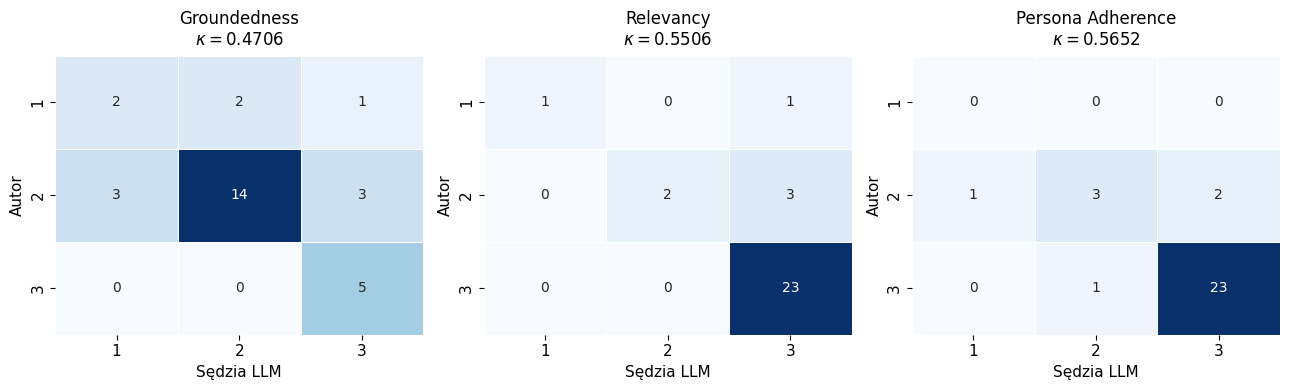

\begin{figure}[h]
\centering
\begin{minipage}{0.32\textwidth}
\centering
\textbf{Groundedness} ($\kappa = 0.47$)\\[4pt]
\begin{tabular}{c|ccc}
\multicolumn{4}{c}{\textit{Sędzia LLM}} \\
\textit{Człowiek} & 1 & 2 & 3 \\\hline
1 & 2 & 2 & 1 \\
2 & 3 & 14 & 3 \\
3 & 0 & 0 & 5 \\
\end{tabular}
\end{minipage} \hfill
\begin{minipage}{0.32\textwidth}
\centering
\textbf{Relevancy} ($\kappa = 0.55$)\\[4pt]
\begin{tabular}{c|ccc}
\multicolumn{4}{c}{\textit{Sędzia LLM}} \\
\textit{Człowiek} & 1 & 2 & 3 \\\hline
1 & 1 & 0 & 1 \\
2 & 0 & 2 & 3 \\
3 & 0 & 0 & 23 \\
\end{tabular}
\end{minipage} \hfill
\begin{minipage}{0.32\textwidth}
\centering
\textbf{Persona Adherence} ($\kappa = 0.57$)\\[4pt]
\begin{tabular}{c|ccc}
\multicolumn{4}{c}{\textit{Sędzia LLM}} \\
\textit{Człowiek} & 1 & 2 & 3 \\\hline
1 & 0 & 0 & 0 \\
2 & 1 & 3 & 2 \\
3 & 0 & 1 & 23 \\
\end{tabular}
\end{minipage}
\caption{Macierze pomyłek dla trzech metryk oceny automatycznej.}
\label{fig:confusion}
\end{figure}


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score

sample = pd.read_csv("final_3/data_eval/dpo_manual_sample_2.csv")

g_ann = {
    0: 2, 1: 3, 2: 1,   # data_engineer chosen
    4: 2, 5: 1, 6: 2,  # data_engineer rejected
    8: 2, 9: 3, 10: 2,  # domain_expert chosen
    12: 1, 13: 2, 14: 2,# domain_expert rejected
    16: 2, 17: 3, 18: 2,# efficient_compute chosen
    20: 2, 21: 2, 22: 2,# efficient_compute rejected
    24: 2, 25: 2, 26: 3,# rigorous_skeptic chosen
    28: 2, 29: 1, 30: 2,# rigorous_skeptic rejected
    32: 3, 33: 2, 34: 2,# sota_chaser chosen
    36: 2, 37: 2, 38: 1# sota_chaser rejected
}
r_ann = {0:3,1:3,2:3,4:3,5:2,6:3,8:3,9:3,10:3,12:3,13:3,14:3,16:3,17:3,18:3,20:1,21:3,22:2,24:3,25:3,26:3,28:3,29:2,30:3,32:3,33:2,34:3,36:2,37:3,38:1}
p_ann = {0:3,1:3,2:3,4:3,5:2,6:2,8:3,9:3,10:3,12:3,13:3,14:3,16:3,17:3,18:3,20:3,21:2,22:3,24:3,25:3,26:2,28:2,29:2,30:3,32:3,33:3,34:3,36:3,37:3,38:3}

metrics = [
    ("Groundedness",      g_ann, "groundedness_score"),
    ("Relevancy",         r_ann, "relevancy_score"),
    ("Persona Adherence", p_ann, "persona_adherence_score"),
]

LABELS = [1, 2, 3]
cms, kappas = [], []
for name, ann, col in metrics:
    idx = sorted(ann.keys())
    human = [ann[i] for i in idx]
    judge = sample.loc[idx, col].tolist()
    cms.append(confusion_matrix(human, judge, labels=LABELS))
    kappas.append(cohen_kappa_score(human, judge))

# ── Heatmaps ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, _, _), cm, k in zip(axes, metrics, cms, kappas):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=LABELS, yticklabels=LABELS,
                linewidths=0.5, cbar=False, vmin=0)
    ax.set_title(f"{name}\n$\\kappa = {k:.4f}$", fontsize=12, pad=8)
    ax.set_xlabel("Sędzia LLM", fontsize=11)
    ax.set_ylabel("Autor", fontsize=11)
    ax.tick_params(axis="both", labelsize=11)

# plt.suptitle("Macierze pomyłek (wiersze = człowiek, kolumny = sędzia LLM)", y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig("final_3/data_eval/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.savefig("final_3/data_eval/confusion_matrices.pdf", bbox_inches="tight")

plt.show()

# ── LaTeX code ────────────────────────────────────────────────────────────────
def cm_to_latex(name, cm, k, labels):
    lines = []
    lines.append(r"\begin{minipage}{0.32\textwidth}")
    lines.append(r"\centering")
    lines.append(f"\\textbf{{{name}}} ($\\kappa = {k:.2f}$)\\\\[4pt]")
    lines.append(r"\begin{tabular}{c|ccc}")
    lines.append(r"\multicolumn{4}{c}{\textit{Sędzia LLM}} \\")
    lines.append("\\textit{Człowiek} & " + " & ".join(str(l) for l in labels) + r" \\\hline")
    for i, label in enumerate(labels):
        row_vals = " & ".join(str(v) for v in cm[i])
        lines.append(f"{label} & {row_vals} \\\\")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{minipage}")
    return "\n".join(lines)

parts = [cm_to_latex(name, cm, k, LABELS) for (name, _, _), cm, k in zip(metrics, cms, kappas)]

latex = (
    "\\begin{figure}[h]\n"
    "\\centering\n"
    + " \\hfill\n".join(parts)
    + "\n\\caption{Macierze pomyłek dla trzech metryk oceny automatycznej.}\n"
    "\\label{fig:confusion}\n"
    "\\end{figure}"
)
print(latex)
